# Hybrid Model Implementation: SARIMAX + XGBoost

This section presents the implementation of a hybrid forecasting model that combines the statistical strength of SARIMAX with the nonlinear learning capability of XGBoost. SARIMAX is first used to capture the linear trend, seasonal structure, and the influence of exogenous variables in the maritime throughput series. The residuals obtained from the SARIMAX model are then modeled using XGBoost to capture nonlinear patterns not explained by the statistical model.

The final hybrid forecast is obtained by adding the SARIMAX forecast and the residual forecast generated by XGBoost. This hybrid framework combines interpretable time-series modeling with a powerful boosting-based residual correction approach.

## Importing Required Libraries

The following libraries are used for data handling, visualization, statistical modeling, machine learning, and performance evaluation.

In [7]:
!pip install xgboost
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
from xgboost import XGBRegressor

## Loading the Dataset

The dataset is loaded into a pandas DataFrame for preprocessing and hybrid forecasting analysis.

In [8]:
df = pd.read_excel(r"C:\Users\Lenovo\Downloads\Maritime_data.xlsx")
df.head()

,Date,Monthly Total TEUs,United States_export_constant_us,United States_export_current_us,United States_import_constant_us,United States_import_current_us,United States_Industry_production,Retail_market
0,01/31/2009 12:00:00 AM,587004.20,85294.39,82415.0,145046.7,130644.1,240000000000,97.06544
1,02/28/2009 12:00:00 AM,413910.30,88213.10,84903.0,137453.7,123590.1,239000000000,96.29944
2,03/31/2009 12:00:00 AM,526487.05,87720.89,83500.0,134329.4,120045.8,235000000000,94.70880
3,04/30/2009 12:00:00 AM,532124.15,85022.69,81088.0,135802.4,121256.0,233000000000,95.10927
4,05/31/2009 12:00:00 AM,574827.80,87143.64,83369.0,129079.8,116262.6,231000000000,95.75613


## Inspecting the Dataset

Before implementing the model, it is necessary to inspect the dataset structure, data types, and column names. This helps identify the target variable and the exogenous variables used in the SARIMAX model.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Date                               93 non-null     object 
 1   Monthly Total TEUs                 93 non-null     float64
 2   United States_export_constant_us   93 non-null     float64
 3   United States_export_current_us    93 non-null     float64
 4   United States_import_constant_us   93 non-null     float64
 5   United States_import_current_us    93 non-null     float64
 6   United States_Industry_production  93 non-null     int64  
 7   Retail_market                      93 non-null     float64
dtypes: float64(6), int64(1), object(1)
memory usage: 5.9+ KB


In [10]:
df.columns.tolist()

['Date',
 'Monthly Total TEUs',
 'United States_export_constant_us',
 'United States_export_current_us',
 'United States_import_constant_us',
 'United States_import_current_us',
 'United States_Industry_production',
 'Retail_market']

## Data Preprocessing

In time series forecasting, the date column must be converted into datetime format and set as the index. The observations are then sorted chronologically and assigned a fixed monthly frequency. This preserves time-series consistency and avoids forecasting issues caused by inferred or misaligned date indices.

In [11]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# Explicit monthly end frequency
df = df.asfreq('ME')

df.head()

,Monthly Total TEUs,United States_export_constant_us,United States_export_current_us,United States_import_constant_us,United States_import_current_us,United States_Industry_production,Retail_market
Date,,,,,,,
2009-01-31,587004.20,85294.39,82415.0,145046.7,130644.1,240000000000,97.06544
2009-02-28,413910.30,88213.10,84903.0,137453.7,123590.1,239000000000,96.29944
2009-03-31,526487.05,87720.89,83500.0,134329.4,120045.8,235000000000,94.70880
2009-04-30,532124.15,85022.69,81088.0,135802.4,121256.0,233000000000,95.10927
2009-05-31,574827.80,87143.64,83369.0,129079.8,116262.6,231000000000,95.75613


## Selecting the Target Variable and Exogenous Variables

The target variable represents monthly maritime throughput, while the selected exogenous variables represent external economic and trade-related information that may influence throughput movements.

The target variable used in this study is **Monthly Total TEUs**. The exogenous variables can be adjusted if your final thesis uses a different subset of explanatory variables.

In [12]:
target_col = 'Monthly Total TEUs'

exog_cols = [
    'United States_export_constant_us',
    'United States_import_constant_us',
    'Retail_market'
]

data = df[[target_col] + exog_cols].copy()
data.head()

,Monthly Total TEUs,United States_export_constant_us,United States_import_constant_us,Retail_market
Date,,,,
2009-01-31,587004.20,85294.39,145046.7,97.06544
2009-02-28,413910.30,88213.10,137453.7,96.29944
2009-03-31,526487.05,87720.89,134329.4,94.70880
2009-04-30,532124.15,85022.69,135802.4,95.10927
2009-05-31,574827.80,87143.64,129079.8,95.75613


## Checking Missing Values

Missing values can reduce model reliability and may create alignment problems between the target series and exogenous variables. Therefore, the selected columns are checked for missing values before model implementation.

In [13]:
data.isnull().sum()

Monthly Total TEUs                  0
United States_export_constant_us    0
United States_import_constant_us    0
Retail_market                       0
dtype: int64

In [14]:
data = data.dropna()
data.isnull().sum()

Monthly Total TEUs                  0
United States_export_constant_us    0
United States_import_constant_us    0
Retail_market                       0
dtype: int64

## Visualizing the Target Series

The target series is plotted to observe its trend, fluctuations, and possible seasonal behavior. This visual inspection supports the use of SARIMAX as the first-stage forecasting model.

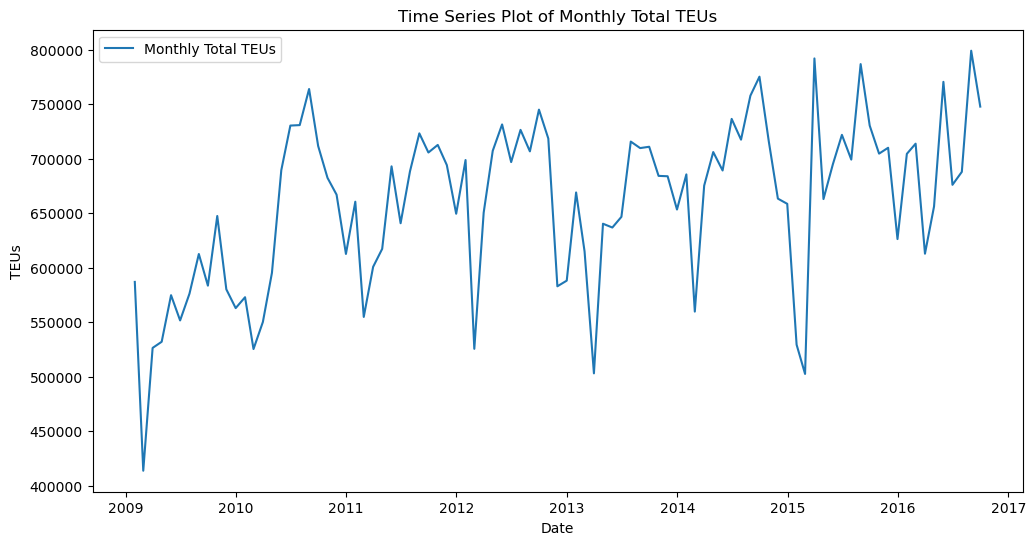

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(data[target_col], label='Monthly Total TEUs')
plt.title('Time Series Plot of Monthly Total TEUs')
plt.xlabel('Date')
plt.ylabel('TEUs')
plt.legend()
plt.show()

## Train-Validation-Test Split

The dataset is divided chronologically into training, validation, and testing sets.

- The **training set** is used to fit the initial SARIMAX model.
- The **validation set** is used to tune the XGBoost residual learner.
- The **testing set** is reserved for final out-of-sample evaluation.

Chronological splitting is essential in time series forecasting because future observations must never be used to predict past values.

In [16]:
n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = data.iloc[:train_end]
val_data = data.iloc[train_end:val_end]
test_data = data.iloc[val_end:]

train_y = train_data[target_col]
val_y = val_data[target_col]
test_y = test_data[target_col]

train_exog = train_data[exog_cols]
val_exog = val_data[exog_cols]
test_exog = test_data[exog_cols]

print("Training Size  :", len(train_data))
print("Validation Size:", len(val_data))
print("Testing Size   :", len(test_data))

Training Size  : 65
Validation Size: 14
Testing Size   : 14


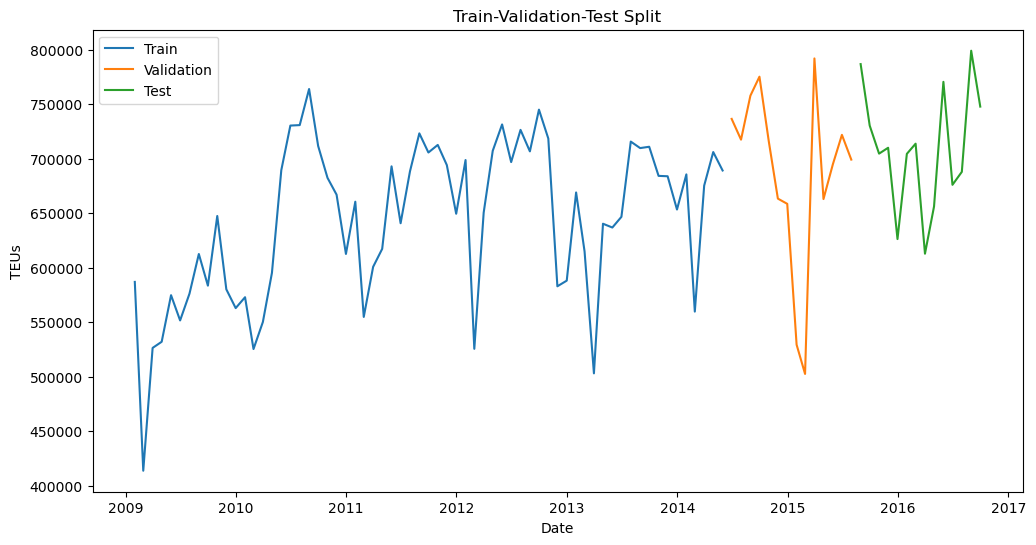

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(train_y, label='Train')
plt.plot(val_y, label='Validation')
plt.plot(test_y, label='Test')
plt.title('Train-Validation-Test Split')
plt.xlabel('Date')
plt.ylabel('TEUs')
plt.legend()
plt.show()

## Base Model: SARIMAX

SARIMAX is used as the first stage of the hybrid framework because it can model trend, seasonality, autocorrelation, and the influence of exogenous variables. This makes it a suitable baseline model for maritime throughput forecasting when throughput is affected by both historical structure and external economic indicators.

## Fitting the SARIMAX Model on Training Data

The SARIMAX model is fitted using the training target series and the selected exogenous variables. The chosen order and seasonal order values can be replaced with the final tuned values used in your thesis.

In [18]:
sarimax_train_model = SARIMAX(
    train_y,
    exog=train_exog,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_train_result = sarimax_train_model.fit(disp=False)
print(sarimax_train_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                 Monthly Total TEUs   No. Observations:                   65
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -465.269
Date:                            Sat, 21 Mar 2026   AIC                            946.538
Time:                                    16:02:23   BIC                            959.638
Sample:                                01-31-2009   HQIC                           951.199
                                     - 05-31-2014                                         
Covariance Type:                              opg                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
United States_export_constant_us     8.9905     10.190      0.882     

## Interpretation of the SARIMAX Summary

The SARIMAX summary provides statistical information about the fitted model, including parameter estimates, information criteria, and diagnostic indicators.

Key points to observe:

- **AIC and BIC** can be used to compare alternative SARIMAX specifications.
- If residual diagnostics suggest remaining structure, then the standalone SARIMAX model has not fully explained the series.
- This provides motivation for using a second-stage nonlinear learner such as XGBoost.

## In-Sample Prediction on Training Data

In-sample predictions are generated for the training period to compute residuals. These residuals represent the unexplained portion of the series after the first-stage SARIMAX model has captured the linear and exogenous effects.

In [19]:
sarimax_train_pred = sarimax_train_result.predict(
    start=train_y.index[0],
    end=train_y.index[-1],
    exog=train_exog
)

sarimax_train_pred.head()

Date
2009-01-31    503753.471140
2009-02-28    592525.371871
2009-03-31    610444.234656
2009-04-30    625775.640199
2009-05-31    638509.227252
Freq: ME, Name: predicted_mean, dtype: float64

## Residual Extraction

Residuals are calculated as the difference between the actual training observations and the fitted values produced by SARIMAX. These residuals contain the nonlinear patterns not captured by the first-stage statistical model.

The first seasonal cycle is removed because differencing-based models often produce unstable fitted values at the beginning of the series.

In [20]:
residuals_train = (train_y - sarimax_train_pred).dropna()
residuals_train = residuals_train.iloc[12:]

residuals_train.head()

Date
2010-01-31   -631161.470482
2010-02-28   -750994.941898
2010-03-31   -748792.001742
2010-04-30   -631441.400143
2010-05-31   -521526.025827
Freq: ME, dtype: float64

## Residual Diagnostics

Residual diagnostics are performed to examine whether structure remains in the SARIMAX residuals. If the residuals are not purely random, then a second-stage nonlinear model is justified.

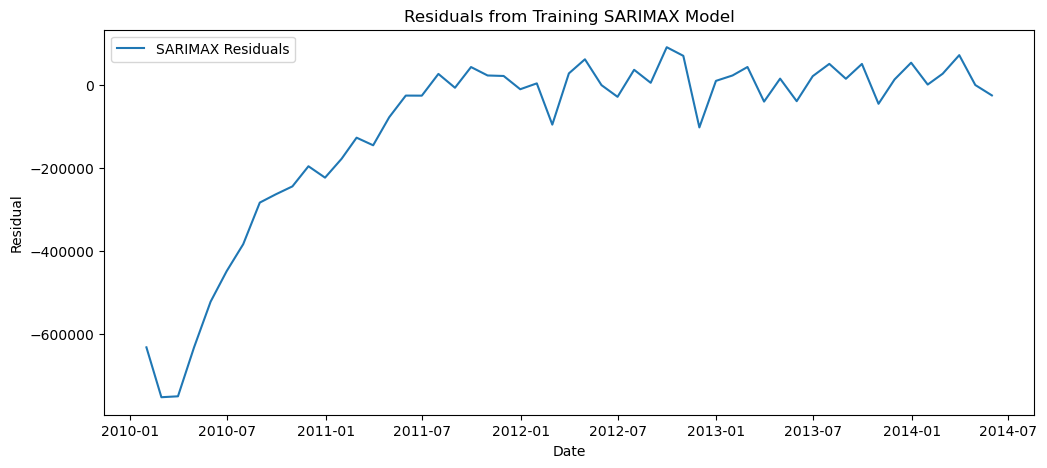

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(residuals_train, label='SARIMAX Residuals')
plt.title('Residuals from Training SARIMAX Model')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.legend()
plt.show()

<Figure size 1000x400 with 0 Axes>

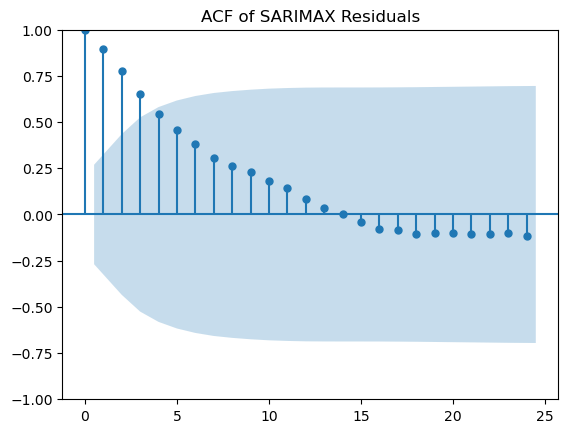

In [22]:
plt.figure(figsize=(10, 4))
plot_acf(residuals_train, lags=24)
plt.title('ACF of SARIMAX Residuals')
plt.show()

In [23]:
lb_test = acorr_ljungbox(residuals_train, lags=[12], return_df=True)
lb_test

,lb_stat,lb_pvalue
12,161.626992,2.447669e-28


## Residual Diagnostics Interpretation

If the residual plot, ACF plot, or Ljung-Box test indicates that structure remains in the residual series, then the first-stage SARIMAX model has not completely captured the data behavior. This supports the use of XGBoost to learn the remaining nonlinear information.

Thus, the hybrid modeling approach is methodologically justified.

## Preparing Residual Features for XGBoost

Since XGBoost is a supervised learning algorithm, the residual series must be transformed into a tabular structure using lag features. For monthly data, both short-term residual lags and a seasonal lag are included. Rolling statistics are also added to provide local trend and variability information.

In [24]:
residual_df = pd.DataFrame({'residual': residuals_train})

for lag in [1, 2, 3, 4, 5, 12]:
    residual_df[f'lag_{lag}'] = residual_df['residual'].shift(lag)

residual_df['rolling_mean_3'] = residual_df['residual'].shift(1).rolling(3).mean()
residual_df['rolling_std_3'] = residual_df['residual'].shift(1).rolling(3).std()

residual_df.dropna(inplace=True)
residual_df.head()

,residual,lag_1,lag_2,lag_3,lag_4,lag_5,lag_12,rolling_mean_3,rolling_std_3
Date,,,,,,,,,
2011-01-31,-178145.226147,-223513.121444,-196140.188611,-244496.505414,-263518.763715,-283441.007279,-631161.470482,-221383.271823,24248.413108
2011-02-28,-127503.569287,-178145.226147,-223513.121444,-196140.188611,-244496.505414,-263518.763715,-750994.941898,-199266.178734,22844.919383
2011-03-31,-145785.288514,-127503.569287,-178145.226147,-223513.121444,-196140.188611,-244496.505414,-748792.001742,-176387.305626,48028.910457
2011-04-30,-78382.900943,-145785.288514,-127503.569287,-178145.226147,-223513.121444,-196140.188611,-631441.400143,-150478.027983,25644.896279
2011-05-31,-26372.726143,-78382.900943,-145785.288514,-127503.569287,-178145.226147,-223513.121444,-521526.025827,-117223.919581,34857.192387


## Feature and Target Preparation

The lagged residual variables and rolling statistics are used as input features, while the current residual value is used as the target variable for XGBoost training.

In [25]:
X_xgb = residual_df.drop('residual', axis=1)
y_xgb = residual_df['residual']

print("Feature shape:", X_xgb.shape)
print("Target shape :", y_xgb.shape)

Feature shape: (41, 8)
Target shape : (41,)


## Helper Functions

The following helper functions are used to compute Mean Absolute Percentage Error (MAPE) and to recursively forecast future residuals using XGBoost.

In [26]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def recursive_xgb_forecast(model, history, feature_columns, steps):
    history = list(history)
    preds = []

    for _ in range(steps):
        s = pd.Series(history)

        row = pd.DataFrame([{
            'lag_1': s.iloc[-1],
            'lag_2': s.iloc[-2],
            'lag_3': s.iloc[-3],
            'lag_4': s.iloc[-4],
            'lag_5': s.iloc[-5],
            'lag_12': s.iloc[-12],
            'rolling_mean_3': s.iloc[-3:].mean(),
            'rolling_std_3': s.iloc[-3:].std()
        }])

        row = row[feature_columns]
        pred = float(model.predict(row)[0])

        preds.append(pred)
        history.append(pred)

    return np.array(preds)

## Training the Initial XGBoost Model

An initial XGBoost model is trained on the residual feature dataset. This provides the baseline second-stage learner before hyperparameter tuning.

In [27]:
xgb_model = XGBRegressor(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=1,
    tree_method='hist',
    verbosity=0
)

xgb_model.fit(X_xgb, y_xgb)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=1, num_parallel_tree=None, ...)

## Validation Forecast Using Training SARIMAX

The SARIMAX model fitted on the training set is used to forecast the validation period. The XGBoost model recursively forecasts residual corrections for the same validation horizon. Both components are then added to form the initial hybrid validation forecast.

In [28]:
sarimax_val_forecast = sarimax_train_result.forecast(
    steps=len(val_y),
    exog=val_exog
)

xgb_val_residual_forecast = recursive_xgb_forecast(
    model=xgb_model,
    history=residuals_train.values,
    feature_columns=X_xgb.columns.tolist(),
    steps=len(val_y)
)

hybrid_val_forecast = pd.Series(
    sarimax_val_forecast.values + xgb_val_residual_forecast,
    index=val_y.index
)

hybrid_val_forecast.head()

Date
2014-06-30    679466.541735
2014-07-31    716517.352894
2014-08-31    736296.659070
2014-09-30    738290.050414
2014-10-31    746652.871965
Freq: ME, dtype: float64

## Validation Performance of the Initial Hybrid Model

The initial hybrid validation forecast is evaluated using MAE, RMSE, and MAPE. These metrics are used for model selection and tuning, not for final reporting.

In [29]:
val_mae = mean_absolute_error(val_y, hybrid_val_forecast)
val_rmse = np.sqrt(mean_squared_error(val_y, hybrid_val_forecast))
val_mape = mean_absolute_percentage_error(val_y, hybrid_val_forecast)

print("Validation Hybrid MAE :", val_mae)
print("Validation Hybrid RMSE:", val_rmse)
print("Validation Hybrid MAPE:", val_mape)

Validation Hybrid MAE : 52239.383274854874
Validation Hybrid RMSE: 70938.2153154488
Validation Hybrid MAPE: 7.92850775270137


## Validation Results Interpretation

The validation results show how well the initial hybrid model performs on unseen intermediate data. These values help assess whether the XGBoost residual learner is effectively improving the SARIMAX baseline during tuning.

The test set is still untouched at this stage, preserving the scientific validity of final out-of-sample evaluation.

## Hyperparameter Tuning for XGBoost

The XGBoost model is tuned using validation-period hybrid forecasting performance. This avoids data leakage and ensures that the final test results remain unbiased.

In [30]:
param_grid = {
    'n_estimators': [30, 50],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

best_rmse = float('inf')
best_params = None
best_model = None

for params in ParameterGrid(param_grid):
    model = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=1,
        tree_method='hist',
        verbosity=0,
        **params
    )

    model.fit(X_xgb, y_xgb)

    temp_residual_forecast = recursive_xgb_forecast(
        model=model,
        history=residuals_train.values,
        feature_columns=X_xgb.columns.tolist(),
        steps=len(val_y)
    )

    temp_hybrid_val = pd.Series(
        sarimax_val_forecast.values + temp_residual_forecast,
        index=val_y.index
    )

    temp_rmse = np.sqrt(mean_squared_error(val_y, temp_hybrid_val))

    if temp_rmse < best_rmse:
        best_rmse = temp_rmse
        best_params = params
        best_model = model

print("Best Parameters:", best_params)
print("Best Validation RMSE:", best_rmse)

Best Parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 50, 'subsample': 0.9}
Best Validation RMSE: 67960.95857910947


## Tuning Interpretation

The best XGBoost parameter combination is selected based on validation RMSE. This configuration is treated as the most suitable residual learner for the final hybrid model because it provides the strongest validation performance on unseen data.

## Refit SARIMAX on Train + Validation Data

After selecting the best XGBoost parameters, the first-stage SARIMAX model is refitted using the combined training and validation data. This ensures that the final test forecast uses all available pre-test information.

In [31]:
trainval_data = data.iloc[:val_end]

trainval_y = trainval_data[target_col]
trainval_exog = trainval_data[exog_cols]

sarimax_trainval_model = SARIMAX(
    trainval_y,
    exog=trainval_exog,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_trainval_result = sarimax_trainval_model.fit(disp=False)
print(sarimax_trainval_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                 Monthly Total TEUs   No. Observations:                   79
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -637.870
Date:                            Sat, 21 Mar 2026   AIC                           1291.739
Time:                                    16:03:41   BIC                           1307.349
Sample:                                01-31-2009   HQIC                          1297.724
                                     - 07-31-2015                                         
Covariance Type:                              opg                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
United States_export_constant_us     7.4526      5.708      1.306     

## Standalone SARIMAX Forecast on the Test Set

The refitted SARIMAX model is used to forecast the final test period. This produces the baseline forecast against which the hybrid model will be compared.

In [32]:
sarimax_test_forecast = sarimax_trainval_result.forecast(
    steps=len(test_y),
    exog=test_exog
)

sarimax_test_forecast.head()

2015-08-31    705843.852276
2015-09-30    744874.375737
2015-10-31    679729.670076
2015-11-30    626916.116748
2015-12-31    606513.932304
Freq: ME, Name: predicted_mean, dtype: float64

## Evaluating the Standalone SARIMAX Baseline

The standalone SARIMAX forecast is evaluated using MAE, RMSE, and MAPE. These values provide the benchmark for judging whether the hybrid model offers an improvement.

In [33]:
sarimax_mae = mean_absolute_error(test_y, sarimax_test_forecast)
sarimax_rmse = np.sqrt(mean_squared_error(test_y, sarimax_test_forecast))
sarimax_mape = mean_absolute_percentage_error(test_y, sarimax_test_forecast)

print("SARIMAX MAE :", sarimax_mae)
print("SARIMAX RMSE:", sarimax_rmse)
print("SARIMAX MAPE:", sarimax_mape)

SARIMAX MAE : 66013.31558680689
SARIMAX RMSE: 80328.96530452577
SARIMAX MAPE: 9.11509704896412


## Baseline Interpretation

The standalone SARIMAX metrics represent the performance of the statistical forecasting model without nonlinear correction. These results must be reported before the hybrid results so that the benefit of hybridization can be clearly demonstrated.

## Residual Preparation from the Refit SARIMAX Model

Residuals are recalculated using the refitted SARIMAX model on the combined training and validation period. These residuals are then used to train the final XGBoost model before generating the hybrid forecast for the test period.

In [34]:
sarimax_trainval_pred = sarimax_trainval_result.predict(
    start=trainval_y.index[0],
    end=trainval_y.index[-1],
    exog=trainval_exog
)

residuals_trainval = (trainval_y - sarimax_trainval_pred).dropna()
residuals_trainval = residuals_trainval.iloc[12:]

residuals_trainval.head()

Date
2010-01-31    -55926.862082
2010-02-28   -101008.975667
2010-03-31   -133767.846762
2010-04-30    -56005.591111
2010-05-31    -20372.779273
Freq: ME, dtype: float64

## Creating the Final Residual Feature Dataset

The final residual feature dataset is built using lagged residual variables and rolling statistics. This dataset is used to train the final tuned XGBoost model.

In [35]:
residual_df_final = pd.DataFrame({'residual': residuals_trainval})

for lag in [1, 2, 3, 4, 5, 12]:
    residual_df_final[f'lag_{lag}'] = residual_df_final['residual'].shift(lag)

residual_df_final['rolling_mean_3'] = residual_df_final['residual'].shift(1).rolling(3).mean()
residual_df_final['rolling_std_3'] = residual_df_final['residual'].shift(1).rolling(3).std()

residual_df_final.dropna(inplace=True)

X_xgb_final = residual_df_final.drop('residual', axis=1)
y_xgb_final = residual_df_final['residual']

print("Final feature shape:", X_xgb_final.shape)
print("Final target shape :", y_xgb_final.shape)

Final feature shape: (55, 8)
Final target shape : (55,)


## Training the Final Tuned XGBoost Model

The final XGBoost model is trained using the best parameter combination obtained during validation tuning. This model is then used to forecast residual corrections for the test period.

In [36]:
final_xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=1,
    tree_method='hist',
    verbosity=0,
    **best_params
)

final_xgb_model.fit(X_xgb_final, y_xgb_final)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=1, num_parallel_tree=None, ...)

## Final Hybrid Forecast on the Test Set

The final hybrid forecast is obtained by combining the SARIMAX baseline forecast and the XGBoost residual forecast. Residuals are forecast recursively for the test horizon and then added to the SARIMAX test predictions.

In [37]:
xgb_test_residual_forecast = recursive_xgb_forecast(
    model=final_xgb_model,
    history=residuals_trainval.values,
    feature_columns=X_xgb_final.columns.tolist(),
    steps=len(test_y)
)

final_hybrid_forecast = pd.Series(
    sarimax_test_forecast.values + xgb_test_residual_forecast,
    index=test_y.index
)

final_hybrid_forecast.head()

Date
2015-08-31    718925.653057
2015-09-30    758360.719487
2015-10-31    706024.756013
2015-11-30    608480.554248
2015-12-31    610381.500175
Freq: ME, dtype: float64

## Evaluating the Final Hybrid Model

The final hybrid model is evaluated using MAE, RMSE, and MAPE. These values are compared against the standalone SARIMAX baseline to determine whether XGBoost successfully captured additional nonlinear information from the residual series.

In [38]:
final_mae = mean_absolute_error(test_y, final_hybrid_forecast)
final_rmse = np.sqrt(mean_squared_error(test_y, final_hybrid_forecast))
final_mape = mean_absolute_percentage_error(test_y, final_hybrid_forecast)

print("Final Hybrid MAE :", final_mae)
print("Final Hybrid RMSE:", final_rmse)
print("Final Hybrid MAPE:", final_mape)

Final Hybrid MAE : 61446.61100499442
Final Hybrid RMSE: 78002.78885347383
Final Hybrid MAPE: 8.494663530043937


## Final Hybrid Results Interpretation

The test results of the hybrid model indicate whether the addition of XGBoost-based residual correction improves forecasting accuracy. If the hybrid model produces lower MAE, RMSE, and MAPE values than the standalone SARIMAX model, then the hybrid framework can be considered successful.

This would imply that the throughput series contains nonlinear residual structure that was not fully captured by SARIMAX alone.

## Results Comparison

A results table is prepared to compare the standalone SARIMAX model and the final SARIMAX + XGBoost hybrid model.

In [39]:
results_df = pd.DataFrame({
    'Model': ['SARIMAX', 'SARIMAX + XGBoost'],
    'MAE': [sarimax_mae, final_mae],
    'RMSE': [sarimax_rmse, final_rmse],
    'MAPE': [sarimax_mape, final_mape]
})

results_df

,Model,MAE,RMSE,MAPE
0,SARIMAX,66013.315587,80328.965305,9.115097
1,SARIMAX + XGBoost,61446.611005,78002.788853,8.494664


## Comparative Conclusion

The comparison table provides the final evidence for the usefulness of the hybrid model. If the hybrid model shows lower forecasting errors than SARIMAX, then hybridization has improved predictive performance by incorporating nonlinear residual learning.

If the improvement is modest, it indicates that nonlinear patterns exist but are limited. If the improvement is substantial, it suggests that a significant portion of the throughput dynamics could only be captured after combining statistical forecasting with boosting-based machine learning.

## Forecast Visualization

The actual test values, standalone SARIMAX forecast, and hybrid forecast are plotted together for visual comparison.

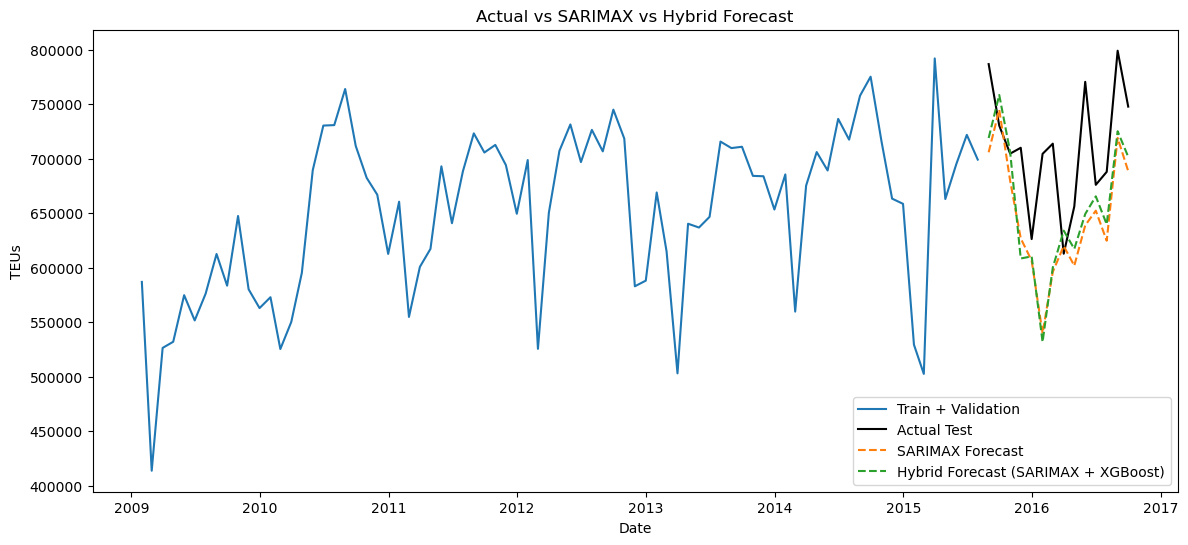

In [40]:
plt.figure(figsize=(14, 6))
plt.plot(trainval_y, label='Train + Validation')
plt.plot(test_y, label='Actual Test', color='black')
plt.plot(sarimax_test_forecast, label='SARIMAX Forecast', linestyle='--')
plt.plot(final_hybrid_forecast, label='Hybrid Forecast (SARIMAX + XGBoost)', linestyle='--')
plt.title('Actual vs SARIMAX vs Hybrid Forecast')
plt.xlabel('Date')
plt.ylabel('TEUs')
plt.legend()
plt.show()

## Final Conclusion

The SARIMAX + XGBoost hybrid model combines the strengths of statistical time-series forecasting and boosting-based nonlinear learning. In the first stage, SARIMAX models trend, seasonality, autocorrelation, and the influence of exogenous variables. In the second stage, XGBoost learns the remaining nonlinear residual structure using lag-based residual features and rolling statistics.

The final hybrid forecast is obtained by adding the SARIMAX baseline forecast and the XGBoost residual forecast. This framework provides a scientifically strong and practically useful approach for maritime throughput forecasting, especially when the data contains both structured seasonal behavior and nonlinear residual variation.